In [40]:
import os
import cv2
import msgpack
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Dropout
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping

In [41]:
print(os.listdir('/kaggle/input/datasets/habedi/large-dataset-of-geotagged-images'))

['shards']


In [42]:
dataset_path = '/kaggle/input/datasets/habedi/large-dataset-of-geotagged-images'

for root, dirs, files in os.walk(dataset_path):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("-"*50)

ROOT: /kaggle/input/datasets/habedi/large-dataset-of-geotagged-images
DIRS: ['shards']
FILES: []
--------------------------------------------------
ROOT: /kaggle/input/datasets/habedi/large-dataset-of-geotagged-images/shards
DIRS: []
FILES: ['shard_24.msg', 'shard_25.msg', 'shard_139.msg', 'shard_74.msg', 'shard_66.msg']
--------------------------------------------------


In [43]:
file_path = "/kaggle/input/datasets/habedi/large-dataset-of-geotagged-images/shards/shard_24.msg"

with open(file_path, "rb") as f:
    unpacker = msgpack.Unpacker(f, raw=False)

    for i, data in enumerate(unpacker):
        print(type(data))
        print(data)

        if i == 0:
            break

<class 'dict'>
{'image': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\x08\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x01@\x02\x02\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\

In [44]:
file_path = "/kaggle/input/datasets/habedi/large-dataset-of-geotagged-images/shards/shard_24.msg"

with open(file_path, "rb") as f:

    unpacker = msgpack.Unpacker(f, raw=False)

    first_item = next(unpacker)

print(first_item.keys())

dict_keys(['image', 'id', 'latitude', 'longitude'])


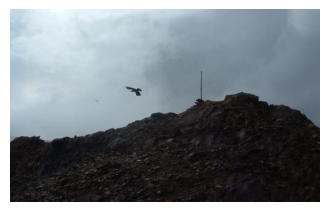

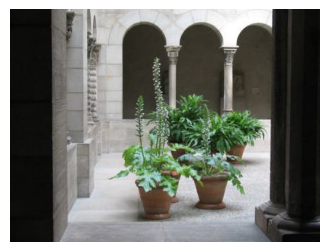

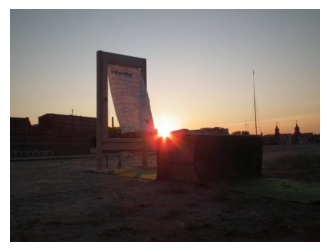

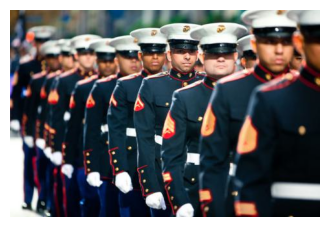

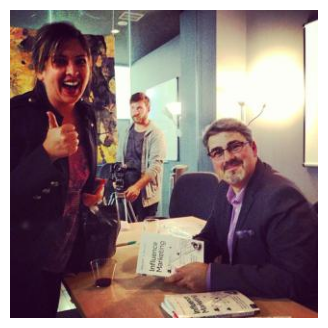

In [45]:
with open(file_path, "rb") as f:
    unpacker = msgpack.Unpacker(f, raw=False)

    for i, item in enumerate(unpacker):
        image_bytes = item['image']
        image_array = np.frombuffer(image_bytes, np.uint8)
        
        image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(4,4))
        plt.imshow(image)
        plt.axis('off')
        plt.show()

        if i == 4:
            break

In [46]:
import msgpack
import numpy as np
import cv2

images = []
targets = []
limit = 1000   

with open(file_path, "rb") as f:
    unpacker = msgpack.Unpacker(f, raw=False)

    for i, item in enumerate(unpacker):
        image_bytes = item['image']
        image_array = np.frombuffer(image_bytes, np.uint8)
        
        image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
        image = cv2.resize(image, (128,128))
        image = image.astype('float32') / 255.0
        images.append(image)

        targets.append([
            item['latitude'],
            item['longitude']
        ])

        if i >= limit:
            break

X = np.array(images, dtype='float32')
y = np.array(targets, dtype='float32')

print(X.shape)
print(y.shape)

(1001, 128, 128, 3)
(1001, 2)


In [47]:
y[:,0] = (y[:,0] + 90) / 180
y[:,1] = (y[:,1] + 180) / 360

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
model = Sequential()

model.add(Conv2D(
    96,
    kernel_size=(11,11),
    strides=4,
    padding='same',
    activation='relu',
    input_shape=(128,128,3)
))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

model.add(Conv2D(
    256,
    kernel_size=(5,5),
    padding='same',
    activation='relu'
))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

model.add(Conv2D(
    384,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))

model.add(BatchNormalization())

model.add(Conv2D(
    384,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))

model.add(BatchNormalization())

model.add(Conv2D(
    256,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))

model.add(BatchNormalization())

model.add(GlobalAveragePooling2D())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2, activation='sigmoid'))

In [56]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 32, 32, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 15, 15, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 15, 15, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,016,130 (15.32 MB)

 Trainable params: 4,013,378 (15.31 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [57]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [58]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

In [59]:
model.compile(
    loss = 'mse',
    optimizer = 'adam',
    metrics = ['mae']
)

In [60]:
history1 = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - loss: 0.0587 - mae: 0.1900 - val_loss: 0.1993 - val_mae: 0.3965 - learning_rate: 0.0010
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0448 - mae: 0.1594 - val_loss: 0.1452 - val_mae: 0.3349 - learning_rate: 0.0010
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0372 - mae: 0.1455 - val_loss: 0.0407 - val_mae: 0.1476 - learning_rate: 0.0010
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0352 - mae: 0.1413 - val_loss: 0.0377 - val_mae: 0.1376 - learning_rate: 0.0010
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0311 - mae: 0.1326 - val_loss: 0.0399 - val_mae: 0.1512 - learning_rate: 0.0010
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0285 - mae: 0.1267 - val_loss: 0.0379 - val_mae: 0.1506 - learning_rate: 0.0010
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0341 - mae: 0.1396
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.000500000023748725

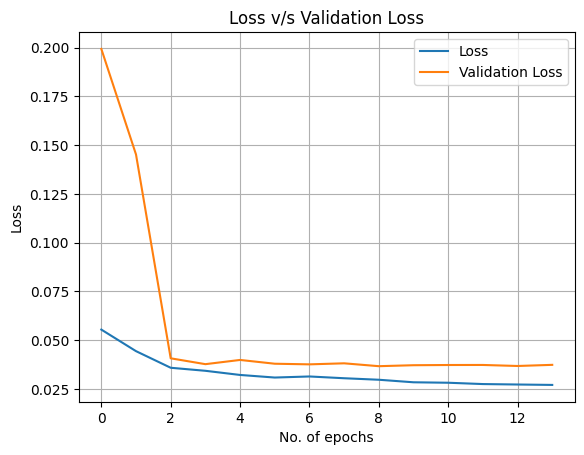

In [62]:
plt.plot(history1.history['loss'], label='Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.xlabel('No. of epochs')
plt.ylabel('Loss')
plt.title('Loss v/s Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

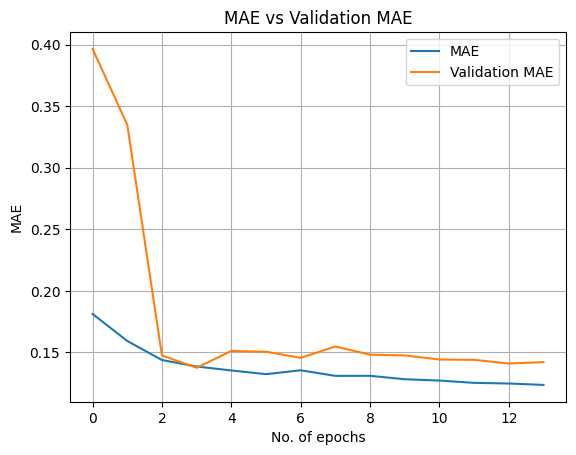

In [63]:
plt.plot(history1.history['mae'], label='MAE')
plt.plot(history1.history['val_mae'], label='Validation MAE')

plt.xlabel('No. of epochs')
plt.ylabel('MAE')
plt.title('MAE vs Validation MAE')

plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


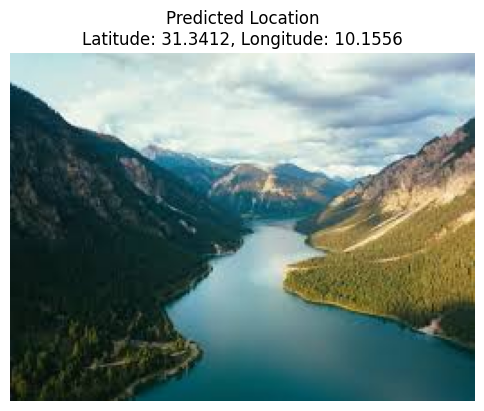

Predicted Latitude : 31.34124
Predicted Longitude: 10.15564


In [65]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/kaggle/input/datasets/aarushkhandelwal/test-dataset/image28.jpeg"   

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128,128))

img_normalized = img_resized.astype('float32') / 255.0
img_input = np.expand_dims(img_normalized, axis=0)


prediction = model.predict(img_input)
pred_lat = prediction[0][0]
pred_lon = prediction[0][1]

pred_lat = pred_lat * 180 - 90
pred_lon = pred_lon * 360 - 180

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Predicted Location\nLatitude: {pred_lat:.4f}, Longitude: {pred_lon:.4f}")
plt.show()

print("Predicted Latitude :", pred_lat)
print("Predicted Longitude:", pred_lon)

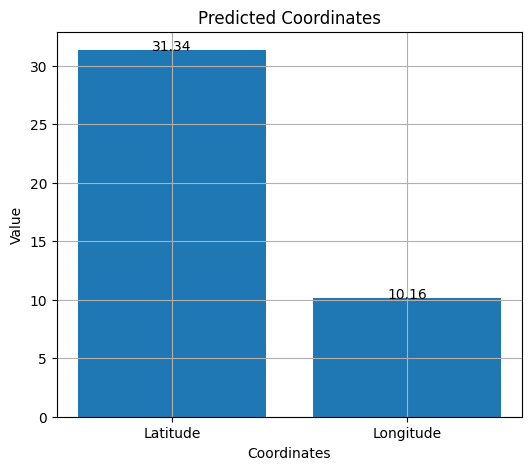

In [66]:
import matplotlib.pyplot as plt

labels = ['Latitude', 'Longitude']
values = [pred_lat, pred_lon]

plt.figure(figsize=(6,5))
plt.bar(labels, values)
plt.xlabel('Coordinates')
plt.ylabel('Value')
plt.title('Predicted Coordinates')

for i, v in enumerate(values):
    plt.text(i, v, f'{v:.2f}', ha='center')

plt.grid(True)

plt.show()